# 可选实验 - 树集成

在本notebook中，你将：

 - 使用Pandas对数据集进行独热编码
 - 使用scikit-learn实现决策树、随机森林和XGBoost模型

让我们导入需要使用的库。

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# !pip install xgboost --quiet
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')

RANDOM_STATE = 55 ## 你将把它传递给每个sklearn调用，以确保可重复性

# 1. 加载数据集

来自 [Kaggle](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

背景
心血管疾病（CVDs）是全球第一大死因，每年估计夺走1790万人的生命，占全球所有死亡的31%。心力衰竭是由心血管疾病引起的常见事件，该数据集包含11个特征，可用于预测可能的心脏病。

患有心血管疾病或处于心血管高风险的人群需要早期检测和管理，机器学习模型可以在此方面提供很大帮助。

你将开发模型来预测一个人患心血管疾病的可能性，基于以下所有信息。

#### 属性信息
- Age: 患者年龄 [年]
- Sex: 患者性别 [M: 男性, F: 女性]
- ChestPainType: 胸痛类型 [TA: 典型心绞痛, ATA: 非典型心绞痛, NAP: 非心绞痛, ASY: 无症状]
- RestingBP: 静息血压 [毫米汞柱]
- Cholesterol: 血清胆固醇 [mm/dl]
- FastingBS: 空腹血糖 [1: 如果FastingBS > 120 mg/dl, 0: 否则]
- RestingECG: 静息心电图结果 [Normal: 正常, ST: 有ST-T波异常（T波倒置和/或ST抬高或压低> 0.05 mV）, LVH: 根据Estes标准显示可能或确定的左心室肥厚]
- MaxHR: 达到的最大心率 [60到202之间的数值]
- ExerciseAngina: 运动诱发的心绞痛 [Y: 是, N: 否]
- Oldpeak: oldpeak = ST [以压低测量的数值]
- ST_Slope: 峰值运动ST段的斜率 [Up: 上升, Flat: 平坦, Down: 下降]
- HeartDisease: 输出类别 [1: 心脏病, 0: 正常]

现在让我们加载数据集。如上所示，变量：

- Sex
- ChestPainType
- RestingECG
- ExerciseAngina
- ST_Slope

是*分类*变量，因此你需要对它们进行独热编码。

In [2]:
# 使用pandas加载数据集
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


在使用模型之前，你必须进行一些数据工程处理。有5个分类特征，因此你将使用Pandas对它们进行独热编码。

## 2. 使用Pandas进行独热编码

首先你需要移除二元变量，因为对它们进行独热编码不会产生任何效果。为此，你只需要计算每个分类变量中有多少个不同的值，并仅考虑有3个或更多值的变量。

In [4]:
cat_variables = ['Sex',
'ChestPainType',
'RestingECG',
'ExerciseAngina',
'ST_Slope'
]

提醒一下，独热编码旨在将具有 `n` 个输出的分类变量转换为 `n` 个二元变量。

Pandas有一个内置方法可以对变量进行独热编码，即 `pd.get_dummies` 函数。该函数有几个参数，但这里你只会使用其中一些。它们是：

 - data: 要使用的DataFrame
 - prefix: 前缀列表，这样你就知道正在处理哪个值
 - columns: 将被独热编码的列列表。'prefix' 和 'columns' 必须具有相同的长度。
 
有关更多信息，你随时可以输入 `help(pd.get_dummies)` 来阅读该函数的完整文档。

In [5]:
# 这将用独热编码的列替换原列，并保持 'columns' 参数之外的列不变。
df = pd.get_dummies(data = df,
                         prefix = cat_variables,
                         columns = cat_variables)

In [6]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


现在你将定义本实验中构建的模型将使用的最终变量集。

In [7]:
var = [x for x in df.columns if x not in 'HeartDisease'] ## 移除目标变量

注意变量数量如何变化。你开始有11个变量，现在你有：

In [8]:
print(len(var))

20


# 3. 分割数据集

在本节中，你将把数据集分为训练集和测试集。你将使用Scikit-learn中的 `train_test_split` 函数。让我们检查一下它的参数。

In [9]:
help(train_test_split)

Help on function train_test_split in module sklearn.model_selection._split:

train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None
)
    Split arrays or matrices into random train and test subsets.

    Quick utility that wraps input validation,
    ``next(ShuffleSplit().split(X, y))``, and application to input data
    into a single call for splitting (and optionally subsampling) data into a
    one-liner.

    Read more in the :ref:`User Guide <cross_validation>`.

    Parameters
    ----------
    *arrays : sequence of indexables with same length / shape[0]
        Allowed inputs are lists, numpy arrays, scipy-sparse
        matrices or pandas dataframes.

    test_size : float or int, default=None
        If float, should be between 0.0 and 1.0 and represent the proportion
        of the dataset to include in the test split. If int, represents the
        absolute number of test samples. If None, the value

In [10]:
X_train, X_test, y_train, y_test = train_test_split(df[var], df['HeartDisease'], train_size = 0.8, random_state = RANDOM_STATE)

# 我们将保持 shuffle = True，因为我们的数据集没有任何时间依赖性。

In [11]:
print(f'训练样本: {len(X_train)}\n测试样本: {len(X_test)}')
print(f'目标比例: {sum(y_train)/len(y_train):.4f}')

训练样本: 734
测试样本: 184
目标比例: 0.5518


# 4. 构建模型

## 4.1 决策树

在本节中，让我们使用你之前学过的决策树，但现在使用 [Scikit-learn实现](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)。

Scikit-learn的DecisionTree对象中有几个超参数。你将只使用其中一些，并且在本实验中不会进行特征选择或超参数调优（但鼓励你这样做并比较结果 :-)）


你将在这里使用和研究的超参数是：

 - min_samples_split: 分割内部节点所需的最小样本数。这可以防止过拟合。
 - max_depth: 树的最大深度。这可以防止过拟合。

In [12]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700] ## 如果数字是整数，则是样本的实际数量，
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, None] # None 表示没有深度限制。

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/

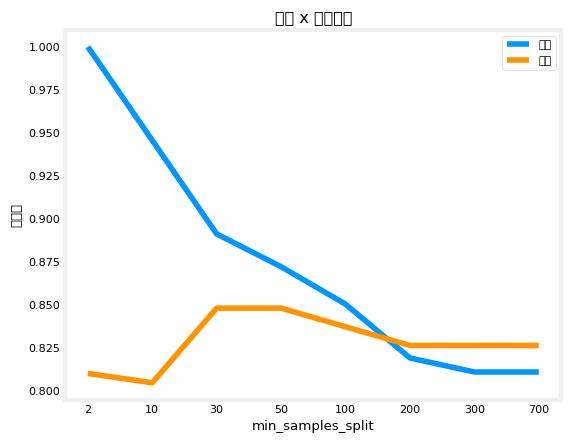

In [13]:
accuracy_list_train = []
accuracy_list_test = []
for min_samples_split in min_samples_split_list:
    # 你可以在定义模型的同时进行拟合，因为fit函数返回拟合后的估计器。
    model = DecisionTreeClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) ## 训练数据集的预测值
    predictions_test = model.predict(X_test) ## 测试数据集的预测值
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('训练 x 测试指标')
plt.xlabel('min_samples_split')
plt.ylabel('准确率')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['训练','测试'])

注意增加 `min_samples_split` 的数量如何减少过拟合。

让我们用 `max_depth` 做同样的实验。

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/

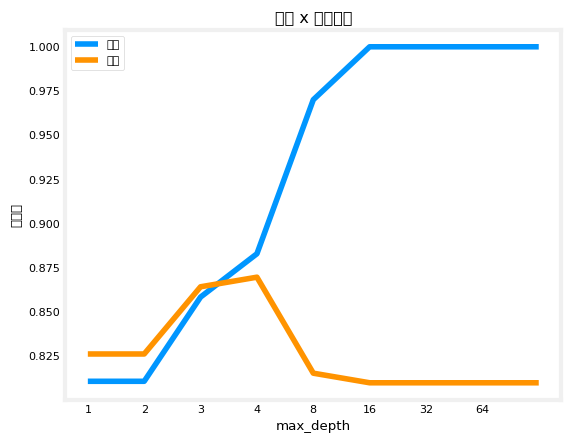

In [14]:
accuracy_list_train = []
accuracy_list_test = []
for max_depth in max_depth_list:
    # 你可以在定义模型的同时进行拟合，因为fit函数返回拟合后的估计器。
    model = DecisionTreeClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) ## 训练数据集的预测值
    predictions_test = model.predict(X_test) ## 测试数据集的预测值
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('训练 x 测试指标')
plt.xlabel('max_depth')
plt.ylabel('准确率')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['训练','测试'])

测试准确率在tree_depth=3时达到最高。当允许的深度较小时，树无法进行足够的分割来区分正例和负例（存在欠拟合问题），但当允许的深度过大（>= 5）时，树会变得过于专业化于训练集，从而在测试数据集上失去准确率（存在过拟合问题）。因此，我们最终的树模型将具有：

- `max_depth = 3`
- `min_samples_split = 50`

In [15]:
decision_tree_model = DecisionTreeClassifier(min_samples_split = 50,
                                             max_depth = 3,
                                             random_state = RANDOM_STATE).fit(X_train,y_train)

In [16]:
print(f"训练指标:\n\t准确率: {accuracy_score(decision_tree_model.predict(X_train),y_train):.4f}\n测试指标:\n\t准确率: {accuracy_score(decision_tree_model.predict(X_test),y_test):.4f}")

训练指标:
	准确率: 0.8583
测试指标:
	准确率: 0.8641


没有过拟合的迹象，尽管指标不是特别好。

## 4.2 随机森林

现在让我们也尝试随机森林算法，使用Scikit-learn的实现。自然，上述所有超参数都将存在于该算法中，因为它只是决策树的集成，但它还有另一个你将使用的超参数，称为 `n_estimators`，即要拟合多少棵不同的决策树。

请记住，对于随机森林，你使用特征的子集和训练集的子集来训练每棵树，这些是随机选择的。在本实验中，你将使用你在讲座中看到的特征数量，即 $\sqrt{n}$，其中 $n$ 是特征的数量。但是，这可以修改。有关随机森林超参数的更多信息，你可以运行 `help(RandomForestClassifier)`。

另一个不影响最终结果但可以加速计算的参数称为 `n_jobs`。由于每棵树的拟合是相互独立的，因此可以进行并行拟合。设置较高的 `n_jobs` 将增加它使用的CPU核心数。请注意，接近CPU最大核心数的数字可能会影响PC的整体性能，甚至导致死机。

你将再次运行相同的脚本，但使用另一个参数 `n_estimators`，我们将在10、50和100之间进行选择。默认值是100。

In [17]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]  ## 如果数字是整数，则是样本的实际数量，
                                             ## 如果是浮点数，则是数据集的百分比
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10,50,100,500]

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/

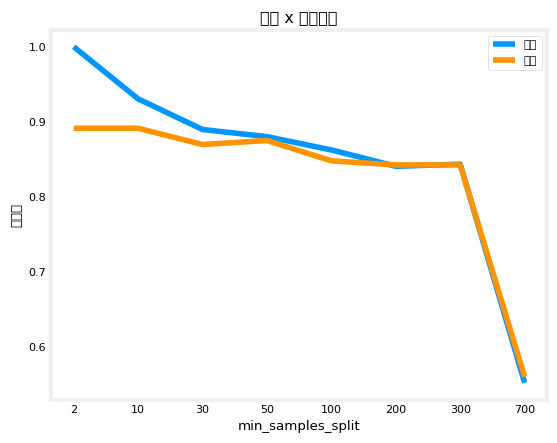

In [18]:
accuracy_list_train = []
accuracy_list_test = []
for min_samples_split in min_samples_split_list:
    # 你可以在定义模型的同时进行拟合，因为fit函数返回拟合后的估计器。
    model = RandomForestClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) ## 训练数据集的预测值
    predictions_test = model.predict(X_test) ## 测试数据集的预测值
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('训练 x 测试指标')
plt.xlabel('min_samples_split')
plt.ylabel('准确率')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list) 
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['训练','测试'])

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/

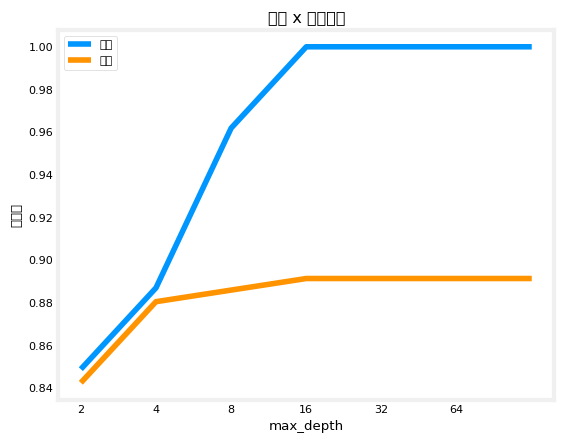

In [19]:
accuracy_list_train = []
accuracy_list_test = []
for max_depth in max_depth_list:
    # 你可以在定义模型的同时进行拟合，因为fit函数返回拟合后的估计器。
    model = RandomForestClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) ## 训练数据集的预测值
    predictions_test = model.predict(X_test) ## 测试数据集的预测值
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('训练 x 测试指标')
plt.xlabel('max_depth')
plt.ylabel('准确率')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['训练','测试'])

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/

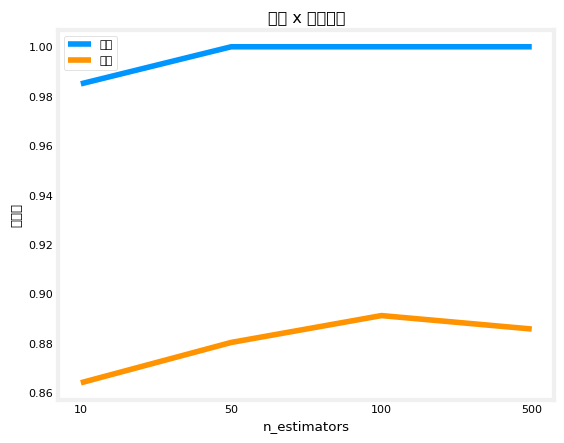

In [20]:
accuracy_list_train = []
accuracy_list_test = []
for n_estimators in n_estimators_list:
    # 你可以在定义模型的同时进行拟合，因为fit函数返回拟合后的估计器。
    model = RandomForestClassifier(n_estimators = n_estimators,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) ## 训练数据集的预测值
    predictions_test = model.predict(X_test) ## 测试数据集的预测值
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('训练 x 测试指标')
plt.xlabel('n_estimators')
plt.ylabel('准确率')
plt.xticks(ticks = range(len(n_estimators_list )),labels=n_estimators_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['训练','测试'])

让我们使用以下参数拟合一个随机森林：

 - max_depth: 8
 - min_samples_split: 10
 - n_estimators: 100

In [21]:
random_forest_model = RandomForestClassifier(n_estimators = 100,
                                             max_depth = 8, 
                                             min_samples_split = 10).fit(X_train,y_train)

In [22]:
print(f"训练指标:\n\t准确率: {accuracy_score(random_forest_model.predict(X_train),y_train):.4f}\n测试指标:\n\t准确率: {accuracy_score(random_forest_model.predict(X_test),y_test):.4f}")

训练指标:
	准确率: 0.9264
测试指标:
	准确率: 0.8859


你已经演示了如何逐个超参数地寻找最佳值。但是，你不应该忽视这样一个事实：当我们对一个超参数进行实验时，我们总是需要将其他超参数固定在某些默认值上。这使得我们只能知道超参数值相对于这些默认值的变化情况。原则上，如果你在要调优的3个超参数中各有4个值要尝试，你总共应该有4 x 4 x 4 = 64种组合，然而，你目前的方法只会给我们4 + 4 + 4 = 12个结果。要尝试所有组合，你可以使用一个名为GridSearchCV的sklearn实现，此外，它有一个refit参数，会自动在最佳组合上重新拟合模型，这样你就不需要显式地编程了。有关GridSearchCV的更多信息，请参阅其[文档](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)。

## 4.3 XGBoost

现在，你在本实验中将测试的最后一个模型是梯度提升模型，称为XGBoost。正如你在讲座中看到的，提升方法训练多棵树，但与它们互不相关不同，现在的树是依次拟合的，以最小化误差。

该模型包含的参数与任何决策树的参数相同，再加上一些其他参数，例如学习率，即XGBoost在内部使用梯度下降方法在每个训练步骤中最小化误差时的步长大小。

关于XGBoost的一个有趣之处是，它允许在拟合期间传入一个形式为 `(X_val,y_val)` 的评估数据集列表，其中在每次迭代中，它会测量评估数据集上的成本（或评估指标），这样当成本（或指标）在一定轮数（称为early_stopping_rounds）内停止下降时，训练就会停止。这就是我们如何自动控制多少估计器就足够了，以及如何避免由于估计器过多而导致的过拟合。

首先，让我们定义训练集的一个子集（我们不应该在这里使用测试集）。

In [23]:
n = int(len(X_train)*0.8) ## 让我们使用80%来训练，20%来评估

In [24]:
X_train_fit, X_train_eval, y_train_fit, y_train_eval = X_train[:n], X_train[n:], y_train[:n], y_train[n:]

然后你可以设置一个较大的估计器数量，因为如果成本函数停止下降，你可以提前停止。

In [25]:
xgb_model = XGBClassifier(n_estimators = 500, learning_rate = 0.1, verbosity = 1, random_state = RANDOM_STATE, early_stopping_rounds = 50)
xgb_model.fit(X_train_fit, y_train_fit, eval_set = [(X_train_eval, y_train_eval)])
# 这里我们必须向eval_set传递一个列表，因为你可以有多个不同的评估集元组。参数
# early_stopping_rounds是它将等待检查成本函数是否下降的迭代次数。
# 如果没有下降，它将停止并获取在评估集上返回最低指标的迭代。

[0]	validation_0-logloss:0.63301
[1]	validation_0-logloss:0.59553
[2]	validation_0-logloss:0.56612
[3]	validation_0-logloss:0.54186
[4]	validation_0-logloss:0.52348
[5]	validation_0-logloss:0.50610
[6]	validation_0-logloss:0.49371
[7]	validation_0-logloss:0.48365
[8]	validation_0-logloss:0.47321
[9]	validation_0-logloss:0.46537
[10]	validation_0-logloss:0.45999
[11]	validation_0-logloss:0.45620
[12]	validation_0-logloss:0.45482
[13]	validation_0-logloss:0.44974
[14]	validation_0-logloss:0.44494
[15]	validation_0-logloss:0.44072
[16]	validation_0-logloss:0.44078
[17]	validation_0-logloss:0.43935
[18]	validation_0-logloss:0.44206
[19]	validation_0-logloss:0.44536
[20]	validation_0-logloss:0.44321
[21]	validation_0-logloss:0.44310
[22]	validation_0-logloss:0.44419
[23]	validation_0-logloss:0.44797
[24]	validation_0-logloss:0.44843
[25]	validation_0-logloss:0.45337
[26]	validation_0-logloss:0.45206
[27]	validation_0-logloss:0.45435
[28]	validation_0-logloss:0.45316
[29]	validation_0-loglos

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

如你所见，尽管你传入了500个估计器进行拟合，但该算法只拟合了66个，因为用于衡量训练轮次的对数损失开始增加了。事实上，估计器的数量甚至少于66。如果你仔细观察指标，你会发现使用16棵拟合的树，我们达到了对数损失的最小值，事实上，这就是最终模型中拟合树的数量：

In [26]:
xgb_model.best_iteration

17

In [27]:
print(f"训练指标:\n\t准确率: {accuracy_score(xgb_model.predict(X_train),y_train):.4f}\n测试指标:\n\t准确率: {accuracy_score(xgb_model.predict(X_test),y_test):.4f}")

训练指标:
	准确率: 0.9319
测试指标:
	准确率: 0.8533


你可以看到随机森林达到了最佳准确率，但总体结果很接近。请注意，XGBoost与随机森林相比，我们获得了非常接近的测试指标，而且我们甚至没有进行任何超参数搜索！XGBoost的优势在于它比随机森林更快，并且它有更多的参数，因此你能够对模型进行微调以获得更好的结果。


恭喜，你已经学会了如何使用scikit-learn库中的决策树、随机森林以及XGBoost！